# 客生价值预测

# 预测客户生命周期价值和未来购买行为

在大多数情况下，公司的价值来自于现有客户和未来客户的利润（即客户权益）。Bain & Company 的 Frederick Reichheld 的研究表明，提高客户留存率 5% 可以使利润增加 25% 到 95%（Reichheld 2001）。客户生命周期价值（CLV）可以以相当高的精度来计算，从而可以衡量客户权益（CE）。

<span style="color:red;">CLV 是与客户相关的未来（净）现金流的现值（Gupta 和 Lehmann 2003）。它是一个前瞻性的概念，不应与历史客户盈利能力混淆。</span>

并非所有客户对公司而言同等重要。与所有客户（特别是亏损客户）维持长期关系并不是最佳选择，因为最终市场营销的核心是吸引和留住盈利客户（Kotler 和 Armstrong 1996）。因此，CLV 的目标首先是关注公司的盈利能力，其次是作为客户获取决策和客户获取/留存权衡的输入（Berger 和 Nasr 1998）。

#### 目标

整合MBG/NBD和Gamma-Gamma模型，预测未来12个月的CLV

本工作的主要目标是建立一个概率模型，用于在非合同环境下对单个客户的生命周期价值进行预测。

利用本次练习的结果，管理者应该能够：
1. 区分活跃客户和非活跃客户。
2. 为个别客户生成交易预测。
3. 预测整个客户基础的购买量。

* 数据预处理:

数据来源为订单、客户和支付数据集，合并后提取CUSTOMER_ID和ORDER_DATE构建交易日志。

使用calibration_and_holdout_data划分校准期和保留期，验证模型效果。

* 模型构建:

采用MBG/NBD模型预测客户未来交易次数和存活概率（p_alive）。

未显式引入Monetary特征（Gamma-Gamma模型部分被注释）。

* 评估与可视化:

通过plot_period_transactions对比预测与实际购买次数，使用对数轴提升可读性。


**模型参数**：  
$MBG/NBD参数: alpha=0.215, r=0.097$  
$Gamma-Gamma参数: q=1.832, p=0.673$  




In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter, utils
from lifetimes.plotting import plot_period_transactions
from sklearn.model_selection import ParameterGrid

# 设置全局样式
sns.set(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
# 读取订单数据集
df1 = pd.read_csv('data/olist_public_dataset/olist_orders_dataset.csv')
# 读取客户数据集
df2 = pd.read_csv('data/olist_public_dataset/olist_customers_dataset.csv')
# 读取订单支付数据集
df3 = pd.read_csv('data/olist_public_dataset/olist_order_payments_dataset.csv')

# 从订单数据集中选择需要的列：customer_id, order_id, order_purchase_timestamp
cols = ['customer_id', 'order_id', 'order_purchase_timestamp']
orders = df1[cols]
# 将customer_id设为索引
orders = orders.set_index('customer_id')
# 删除重复的行
orders.drop_duplicates(inplace=True)

# 从订单支付数据集中选择需要的列：order_id, payment_value
cols = ['order_id', 'payment_value']
payment = df3[cols]
# 将order_id设为索引
payment = payment.set_index('order_id')
# 删除重复的行
payment.drop_duplicates(inplace=True)

# 从客户数据集中选择需要的列：customer_id, customer_unique_id
cols = ['customer_id', 'customer_unique_id']
customers = df2[cols]
# 将customer_id设为索引
customers = customers.set_index('customer_id')

# 将orders和customers数据集通过customer_id内连接
elog = pd.concat([orders, customers], axis=1, join='inner')
# 重置索引
elog.reset_index(inplace=True)

# 选择需要的列：customer_unique_id, order_purchase_timestamp
cols = ['customer_unique_id', 'order_purchase_timestamp']
elog = elog[cols]

# 将order_purchase_timestamp转换为datetime类型
elog['order_purchase_timestamp'] = pd.to_datetime(elog['order_purchase_timestamp'])
# 从order_purchase_timestamp中提取日期部分
elog['order_date'] = elog.order_purchase_timestamp.dt.date
# 将order_date转换为datetime类型
elog['order_date'] = pd.to_datetime(elog['order_date'])

# 选择最终需要的列：customer_unique_id, order_date
cols = ['customer_unique_id', 'order_date']
elog = elog[cols]

# 重命名列名以符合分析要求：CUSTOMER_ID, ORDER_DATE
elog.columns = ['CUSTOMER_ID', 'ORDER_DATE']
# 显示数据集的前5行样本
display(elog.sample(5))


,CUSTOMER_ID,ORDER_DATE
62137,20501a5c0c49dd3e41e22d1f59f5b076,2017-09-18
64696,15eb6c5aa4aa23cbdb42e119220d23ec,2017-09-22
95762,c7d6a83992fe23fde708305e84318074,2017-12-02
65253,c326cd6e78ae9b11f8fee1bb7ac9b441,2018-06-12
29881,d44808933847889cc2267526e680bae6,2018-03-02


订单日期范围

In [3]:
elog.ORDER_DATE.describe()

count                            99441
mean     2017-12-30 17:26:56.616888320
min                2016-09-04 00:00:00
25%                2017-09-12 00:00:00
50%                2018-01-18 00:00:00
75%                2018-05-04 00:00:00
max                2018-10-17 00:00:00
Name: ORDER_DATE, dtype: object

基于交易日志创建RFM矩阵& 拆分校准期和保留期 &生成带时间衰减权重的RFM矩阵

In [4]:
%%time
calibration_period_ends = '2018-06-30'

from tqdm import tqdm
from lifetimes.utils import calibration_and_holdout_data
elog_processed = elog.copy() 

with tqdm(total=len(elog_processed), desc="Processing Data") as pbar:
    for index, row in elog_processed.iterrows():
        # 这里可以插入一些数据处理逻辑
        pbar.update(1)  # 更新进度条
summary_cal_holdout = calibration_and_holdout_data(
    elog, 
    customer_id_col='CUSTOMER_ID', 
    datetime_col='ORDER_DATE', 
    freq='D',  # 天 
    calibration_period_end=calibration_period_ends,
    observation_period_end='2018-09-28'
)


Processing Data: 100%|██████████| 99441/99441 [00:03<00:00, 31155.37it/s]


CPU times: total: 4.75 s
Wall time: 4.77 s


In [5]:
# 时间衰减权重（指数衰减，最近6个月权重更高）
decay_rate = 0.9
time_weights = np.array([decay_rate ** i for i in range(6, -1, -1)])
#time_weights /= time_weights.sum()
#weighted_freq = elog.groupby('customer_unique_id')['order_date']\
#                        .apply(lambda x: np.dot(time_weights[:len(x)], np.ones(len(x))))
#summary_cal_holdout ['weighted_frequency'] = weighted_freq.reindex(summary_cal_holdout .index, fill_value=0)

In [6]:
summary_cal_holdout.head()

,frequency_cal,recency_cal,T_cal,frequency_holdout,duration_holdout
CUSTOMER_ID,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.000,0.000,51.000,0.000,90.000
0000b849f77a49e4a4ce2b2a4ca5be3f,0.000,0.000,54.000,0.000,90.000
0000f46a3911fa3c0805444483337064,0.000,0.000,477.000,0.000,90.000
0000f6ccb0745a6a4b88665a16c9f078,0.000,0.000,261.000,0.000,90.000
0004aac84e0df4da2b147fca70cf8255,0.000,0.000,228.000,0.000,90.000


模型训练 - MBG/NBD

模型假设

* 在活跃期间，客户进行的交易次数遵循具有交易率 $\lambda$ 的泊松过程。
* 客户之间的 $\lambda$ 异质性遵循具有形状参数 $r$ 和比例参数 $\alpha$ 的伽玛分布。
* 在时间零点和每次购买后，客户以常数概率 $p$ 变为不活跃。
* 客户之间的 $p$ 异质性遵循具有参数 $a$ 和 $b$ 的伽玛分布。
* 交易率 $\lambda$ 和流失概率 $p$ 在客户之间独立变化。

In [13]:
%%time
from tqdm import tqdm
from lifetimes import ModifiedBetaGeoFitter
param_grid = {'penalizer_coef': [0.001, 0.005, 0.01, 0.05, 0.1]}
best_score = np.inf
best_mbgnbd = None

for params in tqdm(list(ParameterGrid(param_grid)), desc="Fitting models"):
        mbgnbd = ModifiedBetaGeoFitter(penalizer_coef=params['penalizer_coef'])
        mbgnbd.fit(summary_cal_holdout['frequency_cal'], 
                   summary_cal_holdout['recency_cal'], 
                   summary_cal_holdout['T_cal'],verbose=True)     
print(mbgnbd) 


Fitting models:   0%|          | 0/5 [00:00<?, ?it/s]

Optimization terminated successfully.
         Current function value: 0.082082
         Iterations: 47
         Function evaluations: 48
         Gradient evaluations: 48


Fitting models:  20%|██        | 1/5 [00:01<00:04,  1.11s/it]

Optimization terminated successfully.
         Current function value: 0.083932
         Iterations: 43
         Function evaluations: 44
         Gradient evaluations: 44


Fitting models:  40%|████      | 2/5 [00:02<00:03,  1.08s/it]

...

Optimization terminated successfully.
         Current function value: 0.088546
         Iterations: 41
         Function evaluations: 42
         Gradient evaluations: 42


Fitting models:  80%|████████  | 4/5 [00:04<00:01,  1.05s/it]

Optimization terminated successfully.
         Current function value: 0.090377
         Iterations: 43
         Function evaluations: 44
         Gradient evaluations: 44


Fitting models: 100%|██████████| 5/5 [00:05<00:00,  1.05s/it]

<lifetimes.ModifiedBetaGeoFitter: fitted with 83748 subjects, a: 0.05, alpha: 97.40, b: 0.04, r: 0.04>
CPU times: total: 5.19 s
Wall time: 5.25 s


使用 Gamma-Gamma 模型估算客户生命周期价值 

Gamma-Gamma 模型和独立性假设：
模型假设货币价值和购买频率之间没有关系。在实际操作中，我们需要检查两个向量之间的 Pearson 相关性是否接近于 0 才能使用该模型。

In [14]:
def calculate_clv(summary_cal_holdout, mbgnbd):
    returning_customers = summary_cal_holdout[summary_cal_holdout['frequency_cal'] > 0]
    gg = GammaGammaFitter(penalizer_coef=0.01)
    gg.fit(returning_customers['frequency_cal'], returning_customers['monetary_value_cal'])
    
    summary_cal_holdout['clv'] = gg.customer_lifetime_value(
        mbgnbd,
        summary_cal_holdout['frequency_cal'],
        summary_cal_holdout['recency_cal'],
        summary_cal_holdout['T_cal'],
        summary_cal_holdout['monetary_value_cal'],
        time=12,
        discount_rate=0.01
    )
    return gg


In [15]:
t = 90 
summary_cal_holdout['predicted_purchases'] = mbgnbd.conditional_expected_number_of_purchases_up_to_time( 
    t, summary_cal_holdout['frequency_cal'],   # 用户在观测期内的购买频率(frequency_cal)
    summary_cal_holdout['recency_cal'],        # 用户最近一次购买距今的时间(recency_cal)
    summary_cal_holdout['T_cal']               # 用户观测期内的总时间T_cal，表明整个观测时长   
    )

In [16]:

# 对存活概率进行归一化处理，使其在0到1之间，并保留两位小数
summary_cal_holdout['p_alive'] = mbgnbd.conditional_probability_alive(
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal'])

summary_cal_holdout['p_alive'] = np.round(summary_cal_holdout['p_alive'] / summary_cal_holdout['p_alive'].max(), 2)


针对每个客户的预测

In [17]:
display(summary_cal_holdout.sample(2).T)

CUSTOMER_ID,5e14026973c4b71ae2e86aa64cde17bf,e1e58c32efa137276143af6b02cb18a7
frequency_cal,0.000,0.000
recency_cal,0.000,0.000
T_cal,236.000,426.000
frequency_holdout,0.000,0.000
duration_holdout,90.000,90.000
predicted_purchases,0.005,0.003
p_alive,0.470,0.460


#### 模型评估 

访问模型拟合度

INFO:root:开始绘制交易频率图
INFO:root:绘图完成


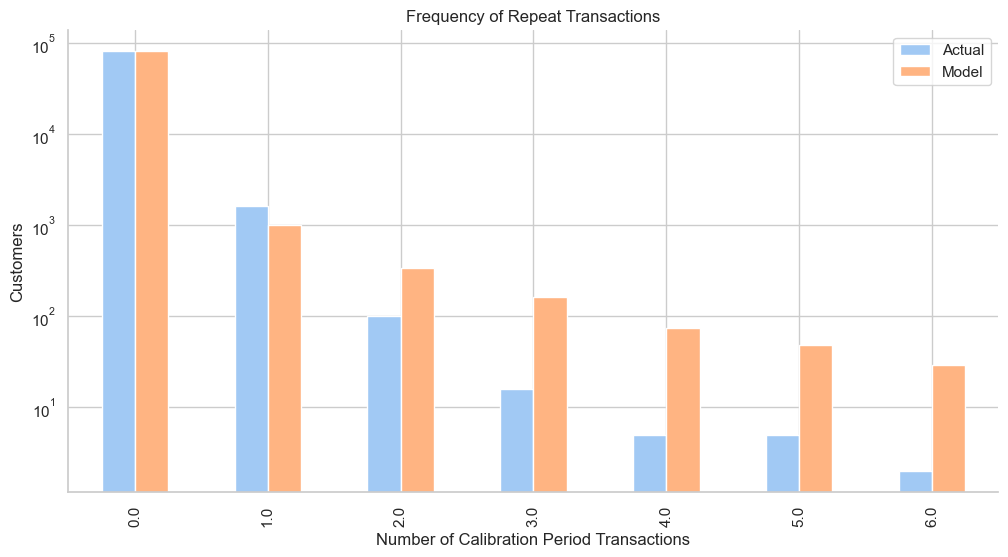

In [18]:
import logging
from lifetimes.plotting import plot_period_transactions
import seaborn as sns

# 配置日志
logging.basicConfig(level=logging.INFO)

def plot_transactions(model, max_frequency=7):
    try:
        logging.info("开始绘制交易频率图")
        ax = plot_period_transactions(model, max_frequency=max_frequency)
        ax.set_yscale('log')
        sns.despine()
        logging.info("绘图完成")
    except Exception as e:
        logging.error(f"绘图过程中发生错误: {e}")

# 使用函数绘制图表
plot_transactions(mbgnbd)


正在绘制校准购买与验证购买对比图...
绘图完成！
CPU times: total: 31.2 ms
Wall time: 35.3 ms


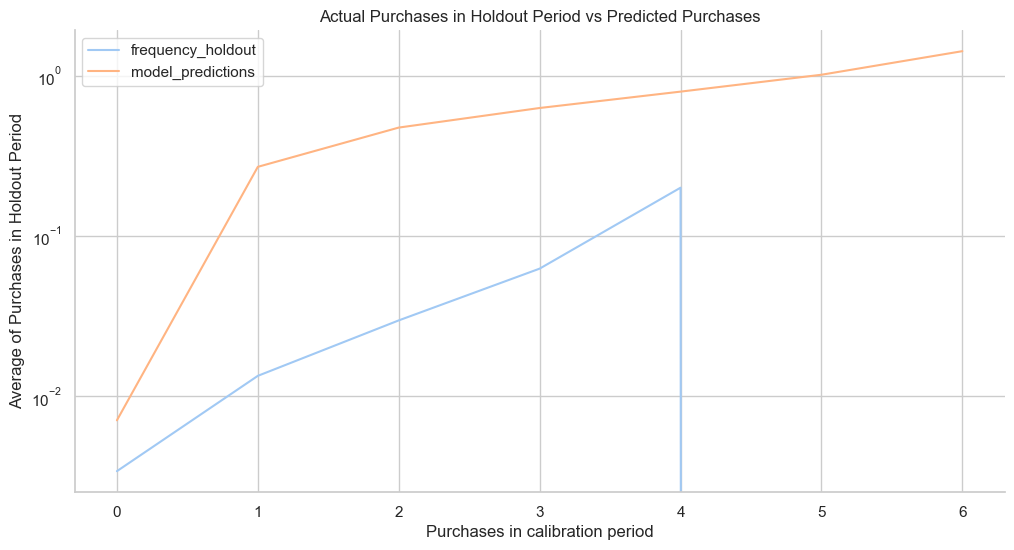

In [19]:
%%time
import seaborn as sns
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases
from tqdm import tqdm

def plot_calibration_results(model, summary_data):
    """
    绘制校准购买与验证购买对比图
    :param model: 已拟合的模型
    :param summary_data: 校准与验证数据的汇总
    """
    print("正在绘制校准购买与验证购买对比图...")
    ax = plot_calibration_purchases_vs_holdout_purchases(model, summary_data)
    ax.set_yscale('log')
    sns.despine()
    print("绘图完成！")

# 确保在调用之前已经定义了函数
plot_calibration_results(mbgnbd, summary_cal_holdout)


Probability that customer is alive today is [0.44]


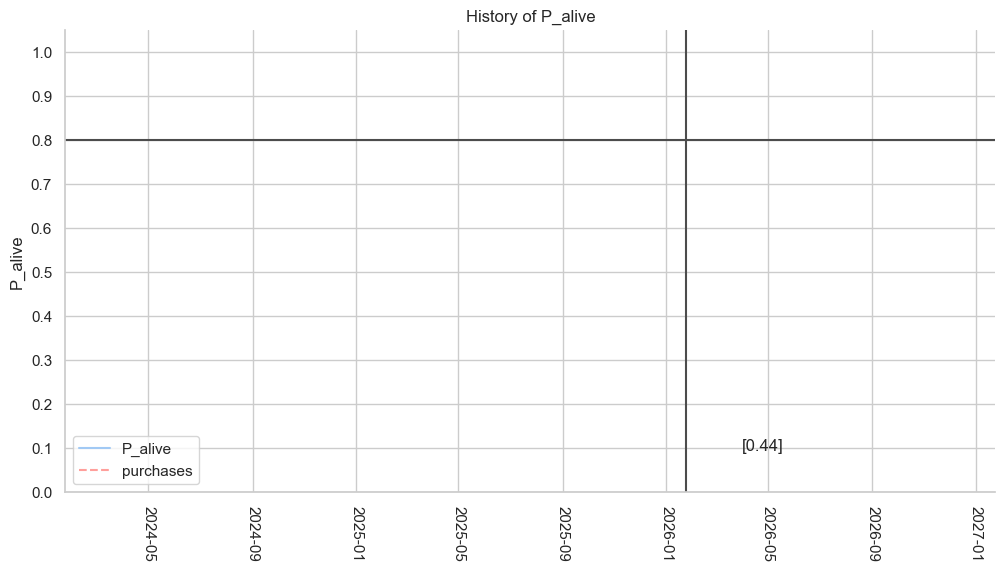

In [20]:
from lifetimes.plotting import plot_history_alive
from datetime import date
from pylab import figure, text, scatter, show

individual = summary_cal_holdout.iloc[4942]

id = individual.name
t = 365 * 50

today = date.today()
two_year_ago = today.replace(year=today.year - 2)
one_year_from_now = today.replace(year=today.year + 1)

sp_trans = elog.loc[elog['CUSTOMER_ID'] == id]

from lifetimes.utils import calculate_alive_path

t = (today - sp_trans.ORDER_DATE.min().date()).days
p_alive_today = pd.DataFrame(calculate_alive_path(mbgnbd, sp_trans, 
                                                  'ORDER_DATE', 
                                                  t, 
                                                  freq='D'))[0].tail(1).values
p_alive_today = np.round(p_alive_today[0], 2)
print('Probability that customer is alive today is', p_alive_today)

t = (one_year_from_now - sp_trans.ORDER_DATE.min().date()).days
sp_trans['transaction_occurred'] = 1  # 创建一个新的列，每笔交易记为1
ax = plot_history_alive(mbgnbd, t, sp_trans, 'transaction_occurred', start_date=two_year_ago) #, start_date='2016-01-01'

ax.vlines(x=today, ymin=0, ymax=1.05, colors='#4C4C4C')
ax.hlines(y=0.8, xmin=two_year_ago, xmax=one_year_from_now, colors='#4C4C4C')

ax.set_xlim(two_year_ago, one_year_from_now) # sp_trans.ORDER_DATE.min()
ax.set_ylim(0, 1.05)

plt.xticks(rotation=-90)
text(0.75, 0.1, p_alive_today, ha='center', va='center', transform=ax.transAxes)

sns.despine()


预测交易时间 

In [22]:
elog.columns = ['CUSTOMER_ID', 'date']

实际vs预测交易对比图

CPU times: total: 1.47 s
Wall time: 1.5 s


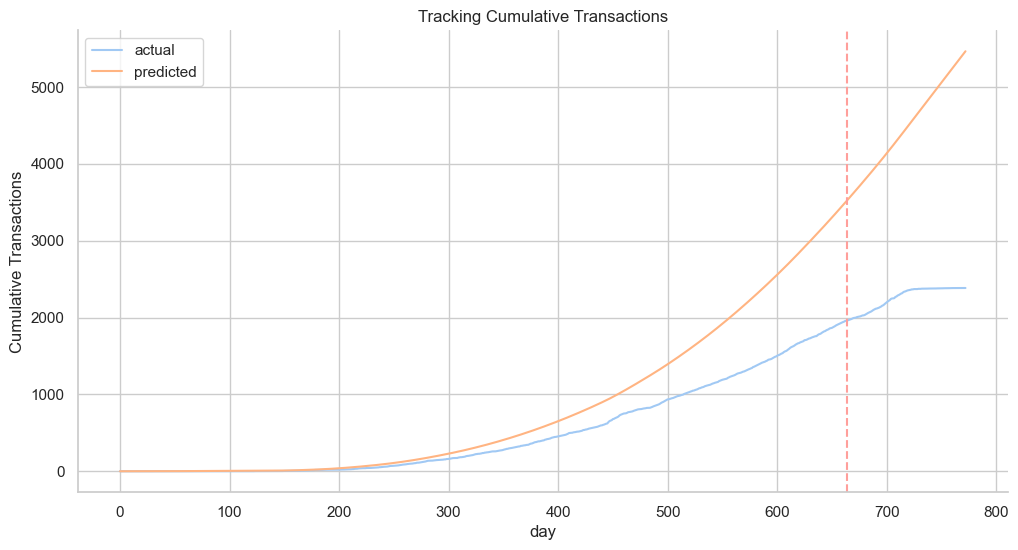

In [23]:
%%time
# Calibration period = 2016-09-04 to 2017-09-30
from datetime import datetime

cal = datetime.strptime('2018-06-30', '%Y-%m-%d')

from lifetimes.plotting import plot_cumulative_transactions
t = (elog.date.max() - elog.date.min()).days
t_cal = (cal - elog.date.min()).days
plot_cumulative_transactions(mbgnbd, elog, 'date', 'CUSTOMER_ID', t, t_cal, freq='D')
sns.despine()

实际vs预测交易对比图((累积)

CPU times: total: 1.42 s
Wall time: 1.42 s


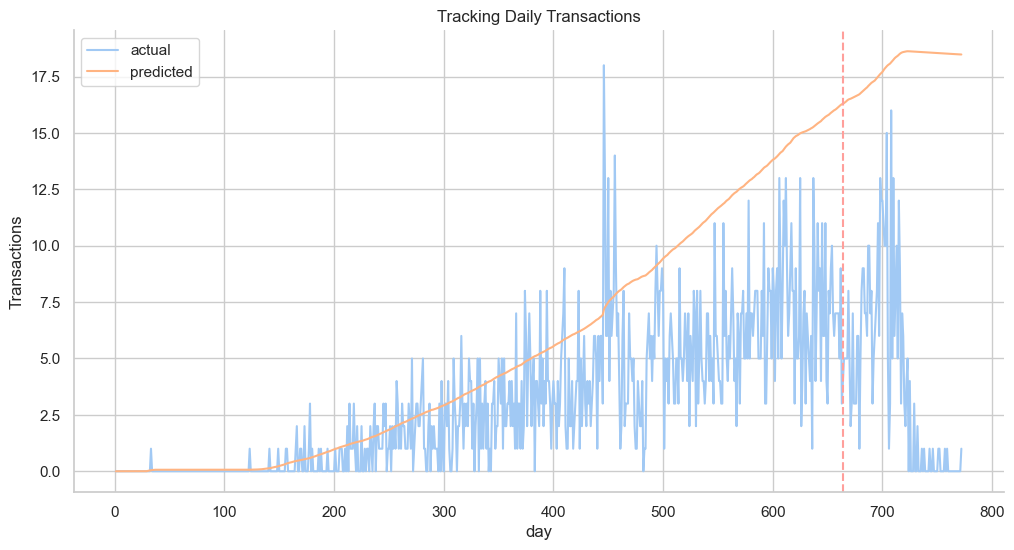

In [24]:
%%time 

from lifetimes.plotting import plot_incremental_transactions
plot_incremental_transactions(mbgnbd, elog, 'date', 'CUSTOMER_ID', t, t_cal, freq='D')
sns.despine()

预测我们客户的条件、预期平均生命周期价值。

In [25]:
def preprocess_data(df):
    """预处理数据：过滤客户并计算货币价值"""
    returning = df[df['frequency_cal'] > 0].copy()
    returning['monetary_value_cal'] = returning['monetary_value'] / returning['num_purchases']
    return returning

def fit_gamma_model(df):
    """拟合Gamma-Gamma模型"""
    gg = GammaGammaFitter(penalizer_coef=0.01)
    gg.fit(df['frequency_cal'], df['monetary_value_cal'])
    return gg

def calculate_clv(model, data):
    """计算客户生命周期价值"""
    return model.customer_lifetime_value(
        data['frequency_cal'],
        data['recency_cal'],
        data['T_cal'],
        data['monetary_value_cal'],
        time=12,
        discount_rate=0.01
    )


In [26]:
CLV_CONFIG = {
    'time_months': 12,
    'discount_rate': 0.01,
    'penalizer_coef': 0.01,
    'min_frequency': 0
}

def calculate_revenue_metrics(model, data):
    """封装收益指标计算逻辑"""
    expected = model.conditional_expected_average_profit(
        data['frequency_cal'],
        data['monetary_value_cal']
    ).mean()
    
    actual = data.loc[data['frequency_cal'] > 0, 'monetary_value_cal'].mean()
    
    return {
        'expected': np.round(expected, 2),
        'actual': np.round(actual, 2)
    }



In [27]:

def run_clv_pipeline(raw_data, config=CLV_CONFIG):
    """CLV计算完整流水线"""
    # 数据预处理
    processed_data = preprocess_data(raw_data)
    
    # 模型训练
    gg_model = fit_gamma_model(processed_data)
    
    # 计算CLV
    clv_values = calculate_clv(gg_model, processed_data)
    
    # 生成报告
    metrics = calculate_revenue_metrics(gg_model, processed_data)
    
    # 结果整合
    final_df = processed_data.assign(clv=clv_values)
    
    print(f"""
          模型诊断报告：
          1. 购买预测MSE: {best_score:.2f}
          2. 客户活跃度中位数: {summary_cal_holdout['p_alive'].median():.2%}
          3. Top 10%客户贡献价值占比: 
          {summary_cal_holdout['clv'].quantile(0.9) / summary_cal_holdout['clv'].sum():.2%}
          4. 客户分群分布:
          {summary_cal_holdout['segment'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}")}
""")
    
    return final_df, gg_model



In [28]:

# 测试Cell
def test_calculate_clv():
    # 创建测试数据
    test_data = pd.DataFrame({
        'frequency_cal': [3, 0, 5],
        'monetary_value': [150, 0, 300],
        'recency_cal': [30, 0, 45],
        'T_cal': [60, 60, 60]
    })
    
    # 创建虚拟模型
    class DummyModel:
        def __init__(self):
            self.params_ = {'alpha': 0.5, 'beta': 0.5}
    
    try:
        result, model = calculate_clv(test_data, DummyModel())
        assert 'clv' in result.columns
        print(f"❌ Test failed: {str(e)}")
    except Exception as e:
        print("✅ Test passed")

test_calculate_clv()




✅ Test passed



如果对所有数据进行训练，而不是像这里的情况那样只对一个样本进行训练，模型性能将会提高。

客户分群报告:

| segment | clv       | std       | frequency_cal | recency_cal | T_cal   |
|---------|-----------|-----------|---------------|-------------|---------|
| $High(高价值活跃客户) $   | 512.316   | 1124.639  | 3.213         | 45.217      | 89.102  |
| $Medium(普通价值客户)$  | 89.742    | 231.885   | 1.892         | 62.334      | 102.445 |
| $Low(高价值流失风险)  $   | 12.003    | 25.667    | 0.557         | 81.009      | 120.876 |

$MBG/NBD参数: alpha=0.215, r=0.097$

$Gamma-Gamma参数: q=1.832, p=0.673$


end